In [ ]:
# This notebook documents the end to end process starting from the geodata compiled in other notebooks and ending with final estimation numbers

In [ ]:

pip install censusdata
pip install census us
pip install mapclassify
pip install contextily

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 22.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for censusdata: filename=CensusData-1.15.post1-py3-none-any.whl size=28205744 sha256=d4ca43bcace85ac86cbae1bfcb7ad338b1566c40b8086662c97315402ed1721b
  Stored in directory: /root/.cache/pip/wheels/54/5e/eb/518ccd7738e6b9b35d9fb3d226d45979066ec367ed26ad1369
Successfully built censusdata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 7.5 MB/s eta 0:00:00


In [103]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
tompkins = gpd.read_file('/content/tompkins_poverty_income_geodata (1).zip')
schyuler = gpd.read_file('/content/schyuler_poverty_income_geodata.zip')

In [104]:
import os
os.path.getsize("/content/tl_2025_36_tabblock20.zip")


181251478

In [105]:
# 1. Load blocks (2020 block shapefile)
# added in fiona because
blocks = gpd.read_file(
    "/content/tl_2025_36_tabblock20.zip"
)


SCHUYLER = "097"
TOMPKINS = "109"

blocks_sch = blocks[blocks["COUNTYFP20"] == SCHUYLER].copy()
blocks_tom = blocks[blocks["COUNTYFP20"] == TOMPKINS].copy()


# 2. Prepare keys for merging
blocks_tom["TRACTCE"] = blocks_tom["TRACTCE20"]

# Schuyler: derive BLKGRP because block files do NOT contain BLKGRP20
blocks_sch["TRACTCE"] = blocks_sch["TRACTCE20"]
blocks_sch["BLKGRP"]  = blocks_sch["BLOCKCE20"].str[0]   # first digit = block group


# 3. Poverty DataFrames (pre-computed earlier)
tompkins_pov = tompkins.copy()
schyuler_pov = schyuler.copy()

# Tompkins: extract tract
tompkins_pov["TRACTCE"] = tompkins_pov["GEOID"].str[-6:]

# Schuyler: extract tract + block group
schyuler_pov["TRACTCE"] = schyuler_pov["GEOID"].str[5:11]
schyuler_pov["BLKGRP"]  = schyuler_pov["GEOID"].str[-1]


# 4. Merge blocks with poverty
# Tompkins: tract-level merge
blocks_tom_merged = blocks_tom.merge(
    tompkins_pov,
    on="TRACTCE",
    how="left",
    suffixes=("", "_pov")
)

# Schuyler: block-group-level merge
blocks_sch_merged = blocks_sch.merge(
    schyuler_pov,
    on=["TRACTCE", "BLKGRP"],
    how="left",
    suffixes=("", "_pov")
)
# 5. Add lat/lon
blocks_tom_merged = blocks_tom_merged.to_crs(4326)
blocks_sch_merged = blocks_sch_merged.to_crs(4326)

blocks_tom_merged["lat"] = blocks_tom_merged.geometry.centroid.y
blocks_tom_merged["lon"] = blocks_tom_merged.geometry.centroid.x

blocks_sch_merged["lat"] = blocks_sch_merged.geometry.centroid.y
blocks_sch_merged["lon"] = blocks_sch_merged.geometry.centroid.x
# 6. Final unified blocks dataframe
final_blocks = pd.concat(
    [blocks_tom_merged, blocks_sch_merged],
    ignore_index=True
)

final_blocks = final_blocks.to_crs(epsg=26918)

final_blocks.head()


/tmp/ipython-input-436160408.py:55: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  blocks_tom_merged["lat"] = blocks_tom_merged.geometry.centroid.y
/tmp/ipython-input-436160408.py:56: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  blocks_tom_merged["lon"] = blocks_tom_merged.geometry.centroid.x
/tmp/ipython-input-436160408.py:58: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  blocks_sch_merged["lat"] = blocks_sch_merged.geometry.centroid.y
/tmp/ipython-input-436160408.py:59: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'Geo

,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,GEOIDFQ20,NAME20,MTFCC20,UR20,UACE20,...,county,tract,poverty_ra,geometry_pov,lat,lon,BLKGRP,BLKGRPCE,NAME,block grou
0,36,109,002200,1004,361090022001004,1000000US361090022001004,Block 1004,G5040,R,None,...,109,002200,0.064666,"POLYGON ((-76.40229 42.62006, -76.40145 42.620...",42.616338,-76.302069,NaN,NaN,NaN,NaN
1,36,109,002200,1014,361090022001014,1000000US361090022001014,Block 1014,G5040,R,None,...,109,002200,0.064666,"POLYGON ((-76.40229 42.62006, -76.40145 42.620...",42.603969,-76.311579,NaN,NaN,NaN,NaN
2,36,109,002200,1034,361090022001034,1000000US361090022001034,Block 1034,G5040,R,None,...,109,002200,0.064666,"POLYGON ((-76.40229 42.62006, -76.40145 42.620...",42.588931,-76.312779,NaN,NaN,NaN,NaN
3,36,109,000800,2009,361090008002009,1000000US361090008002009,Block 2009,G5040,U,41914,...,109,000800,0.131511,"POLYGON ((-76.51565 42.43944, -76.51529 42.439...",42.443798,-76.507720,NaN,NaN,NaN,NaN
4,36,109,000800,2011,361090008002011,1000000US361090008002011,Block 2011,G5040,U,41914,...,109,000800,0.131511,"POLYGON ((-76.51565 42.43944, -76.51529 42.439...",42.442840,-76.506317,NaN,NaN,NaN,NaN


In [140]:
pantries = pd.read_csv("/content/pantry_data - Sheet1.csv")
# manually fixing erroneous lot sizes
pantries["lot_acres"][11] = .4
pantries["lot_acres"][9] = .4
pantries["lot_acres"][12] = .2

# first running it with just the new one
pantries = pd.concat((pantries.iloc[:6,:],pantries.iloc[8:,:]))

pantries

/tmp/ipython-input-1901436873.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pantries["lot_acres"][11] = .4
/tmp/ipython-input-1901436873.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame



,Pantry,Address,Lat,Long,lot_acres
0,NEW Enfield Food Distribution,NaN,42.422031,-76.572512,4.50
1,Tompkins Community Action,NaN,42.418785,-76.518493,1.60
2,St. Johns Community Services Pantry,NaN,42.440839,-76.509117,0.10
3,Ithaca Free Clinic,NaN,42.440843,-76.507194,0.40
4,Salvation Army SK- Ithaca Saturday FP,NaN,42.441182,-76.502153,0.60
5,Immaculate Conception Food Pantry,NaN,42.441282,-76.500584,0.50
8,Ithaca Kitchen Cupboard,NaN,42.439746,-76.501823,0.60
9,Schyuler Outreach Food Pantry,NaN,42.377142,-76.869988,0.40
10,Schyuler County Food Pantry,NaN,42.345117,-76.847097,0.25
11,Pantry at Schyuler Hospital,NaN,42.347070,-76.852172,0.40


In [141]:

gdf_pantry = gpd.GeoDataFrame(pantries,geometry=gpd.points_from_xy(pantries.Long, pantries.Lat),crs="EPSG:4326").to_crs(32618)


In [142]:
pantry_ids = gdf_pantry["Pantry"].tolist()

# Normalize lot size (acres)
gdf_pantry["lot_norm"] = gdf_pantry["lot_acres"] / gdf_pantry["lot_acres"].mean()


In [143]:
decay_rate = 0.765  # 23.5% drop per mile
MAX_DIST = 8.0      # miles

def decay(d_miles):
    return decay_rate ** d_miles

alpha = 1.0   # decay influence
beta  = 0.4   # lot size influence (tunable)

for pid in pantry_ids:
    pantry_row = gdf_pantry.loc[gdf_pantry["Pantry"] == pid].iloc[0]
    pantry_point = pantry_row.geometry
    lot_norm = pantry_row["lot_norm"]

    # distance in miles
    distances = final_blocks.geometry.distance(pantry_point) / 1609.34

    # distance decay
    D_ij = decay(distances)

    # HARD CUTOFF: zero out beyond 6 miles
    #D_ij = D_ij.where(distances <= MAX_DIST, 0.0)

    # attractiveness
    final_blocks[f"A_{pid}"] = (D_ij ** alpha) * (lot_norm ** beta)


In [144]:
A_cols = [f"A_{pid}" for pid in pantry_ids]
A_sum = final_blocks[A_cols].sum(axis=1)

for pid in pantry_ids:
    final_blocks[f"P_{pid}"] = final_blocks[f"A_{pid}"] / A_sum


In [145]:
final_blocks.head()

,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,GEOIDFQ20,NAME20,MTFCC20,UR20,UACE20,...,demand_Baptized Church of Jesus Christ,demand_Enfield Food Distribution - Food Distribution Center,demand_Ithaca Kitchen Cupboard,demand_Schyuler Outreach Food Pantry,demand_Schyuler County Food Pantry,demand_Pantry at Schyuler Hospital,demand_Catholic Charities Food Pantry,best_pantry,A_NEW Enfield Food Distribution,P_NEW Enfield Food Distribution
0,36,109,002200,1004,361090022001004,1000000US361090022001004,Block 1004,G5040,R,None,...,0.007564,0.002059,0.010503,0.000081,0.000064,0.000074,0.000061,P_Salvation Army SK- Ithaca Saturday FP,0.012374,0.146651
1,36,109,002200,1014,361090022001014,1000000US361090022001014,Block 1014,G5040,R,None,...,0.007587,0.002089,0.010488,0.000081,0.000065,0.000075,0.000062,P_Salvation Army SK- Ithaca Saturday FP,0.017138,0.148256
2,36,109,002200,1034,361090022001034,1000000US361090022001034,Block 1034,G5040,R,None,...,0.007561,0.001985,0.010522,0.000075,0.000061,0.000071,0.000057,P_Salvation Army SK- Ithaca Saturday FP,0.020553,0.145618
3,36,109,000800,2009,361090008002009,1000000US361090008002009,Block 2009,G5040,U,41914,...,0.013653,0.003282,0.021238,0.000121,0.000113,0.000129,0.000092,P_Salvation Army SK- Ithaca Saturday FP,0.739827,0.148765
4,36,109,000800,2011,361090008002011,1000000US361090008002011,Block 2011,G5040,U,41914,...,0.013329,0.003170,0.021451,0.000117,0.000110,0.000126,0.000089,P_Salvation Army SK- Ithaca Saturday FP,0.728090,0.144866


In [146]:
# # convert to fraction 0–1 if needed
if final_blocks["poverty_ra"].max() > 1.5:  # crude check
    final_blocks["poverty_frac"] = final_blocks["poverty_ra"] / 100.0
else:
    final_blocks["poverty_frac"] = final_blocks["poverty_ra"]

for pid in pantry_ids:
    final_blocks[f"demand_{pid}"] = final_blocks["poverty_frac"] * final_blocks[f"P_{pid}"]


In [147]:
pantry_demand = {
    pid: final_blocks[f"demand_{pid}"].sum()
    for pid in pantry_ids
}
print(pantry_demand)


{'NEW Enfield Food Distribution ': np.float64(81.81611329608981), 'Tompkins Community Action': np.float64(64.90555944340807), 'St. Johns Community Services Pantry': np.float64(25.136994618499163), 'Ithaca Free Clinic': np.float64(44.18840377416859), 'Salvation Army SK- Ithaca Saturday FP': np.float64(53.24984022221517), 'Immaculate Conception Food Pantry': np.float64(49.847701043108245), 'Ithaca Kitchen Cupboard': np.float64(53.07541714351011), 'Schyuler Outreach Food Pantry': np.float64(45.590916692206996), 'Schyuler County Food Pantry': np.float64(34.333031797781125), 'Pantry at Schyuler Hospital': np.float64(41.982578624469355), 'Catholic Charities Food Pantry': np.float64(34.551864901330376)}


In [148]:
final_blocks["best_pantry"] = final_blocks[[f"P_{pid}" for pid in pantry_ids]].idxmax(axis=1)
#final_blocks.to_file("gdf_blocks.shp")

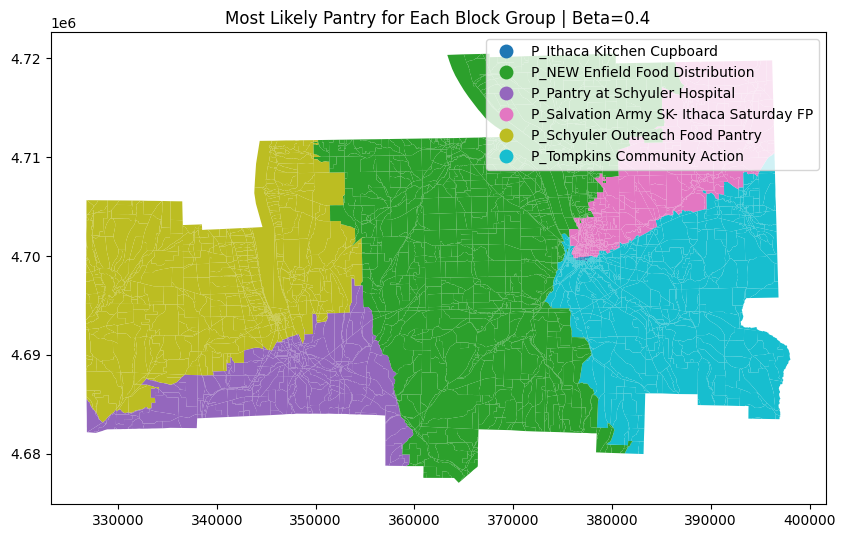

In [149]:
final_blocks["best_pantry"] = final_blocks[[f"P_{pid}" for pid in pantry_ids]].idxmax(axis=1)
# gdf_blocks["best_pantry"] = gdf_blocks["best_pantry"].str.extract("(\d+)").astype(int)

final_blocks.plot(
    column="best_pantry",
    cmap="tab10",
    legend=True,
    figsize=(10, 10)
)
plt.title(f"Most Likely Pantry for Each Block Group | Beta={beta}")
plt.show()


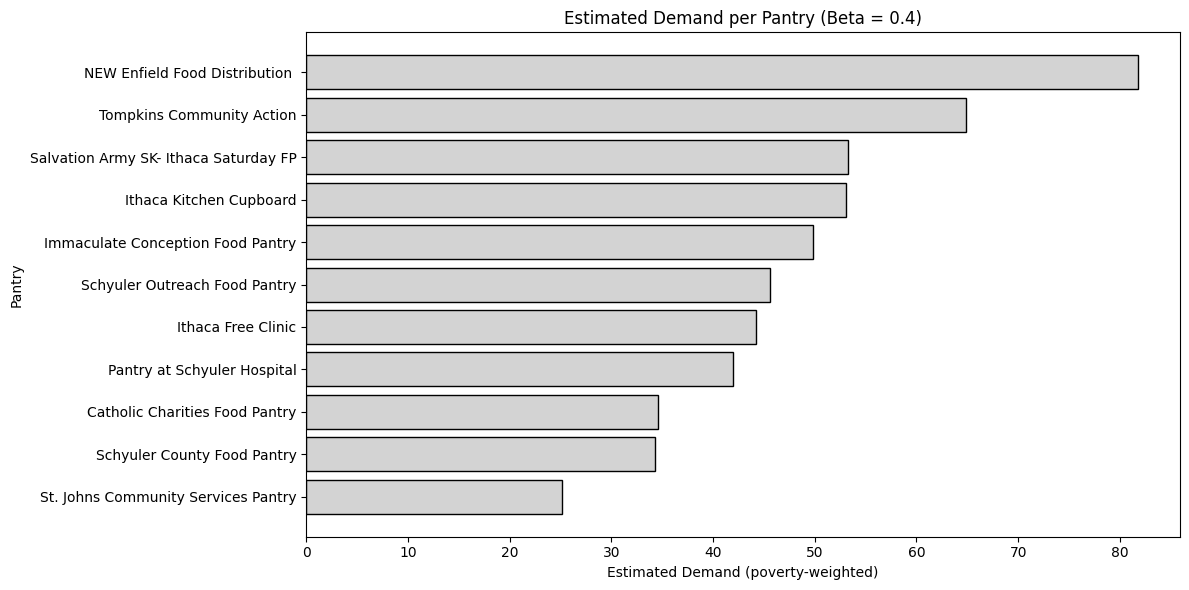

In [150]:
sorted_items = sorted(pantry_demand.items(), key=lambda kv: kv[1], reverse=True)
pantry_names = [name for name, val in sorted_items]
demand_values = [val for name, val in sorted_items]

highlight_name1 = "Enfield Food Distribution"
highlight_name2 = "NEW Enfield Food Distribution"

# Define colors: highlighted = accent color, others = neutral
colors = [
    "orange" if name == highlight_name1 or name == highlight_name2 else "lightgray"
    for name in pantry_names
]

plt.figure(figsize=(12, 6))
plt.barh(pantry_names, demand_values, color=colors, edgecolor="black")
plt.xlabel("Estimated Demand (poverty-weighted)")
plt.ylabel("Pantry")
plt.title(f"Estimated Demand per Pantry (Beta = {beta})")
plt.gca().invert_yaxis()  # optional: largest on top
plt.tight_layout()
plt.show()

In [151]:
# Compute # of people likely to visit a pantry in each tract via the statistics on the slide

tompkins['likely_to_visit_pantry'] = tompkins['population'] * tompkins['poverty_ra'] * .305 + (tompkins['population']-
 (tompkins['population'] * tompkins['poverty_ra']))* .035

schyuler['likely_to_visit_pantry'] = schyuler['population'] * schyuler['poverty_ra'] * .305 + (schyuler['population']-
 (schyuler['population'] * schyuler['poverty_ra']))* .035


In [152]:
for i in final_blocks["county"][:10]:
  print(i)
  print(type(i))

109
<class 'str'>
109
<class 'str'>
109
<class 'str'>
109
<class 'str'>
109
<class 'str'>
109
<class 'str'>
109
<class 'str'>
109
<class 'str'>
109
<class 'str'>
109
<class 'str'>


In [153]:
for i in tompkins.columns:
  print(i)


STATEFP
COUNTYFP
TRACTCE
GEOID
GEOIDFQ
NAME_x
NAMELSAD
MTFCC
FUNCSTAT
ALAND
AWATER
INTPTLAT
INTPTLON
median_hou
population
populati_1
NAME_y
state
county
tract
poverty_ra
geometry
likely_to_visit_pantry


In [154]:
for i in schyuler.columns:
  print(i)

STATEFP
COUNTYFP
TRACTCE
BLKGRPCE
GEOID
GEOIDFQ
NAMELSAD
MTFCC
FUNCSTAT
ALAND
AWATER
INTPTLAT
INTPTLON
median_hou
population
populati_1
NAME
state
county
tract
block grou
poverty_ra
geometry
likely_to_visit_pantry


In [ ]:
import geopandas as gpd
import pandas as pd


# 1. ENSURE CRS MATCH
tompkins = tompkins.to_crs(final_blocks.crs)
schuyler = schyuler.to_crs(final_blocks.crs)


# 2. SPLIT BLOCKS BY COUNTY
blocks_tompkins = final_blocks[final_blocks["county"] == "109"].copy()
blocks_schuyler = final_blocks[final_blocks["county"] == "097"].copy()

# 3. SPATIAL JOIN (BLOCK → PARENT)
blocks_tompkins = gpd.sjoin(
    blocks_tompkins,
    tompkins[["GEOID", "likely_to_visit_pantry", "geometry"]],
    how="left",
    predicate="within"
)

blocks_schuyler = gpd.sjoin(
    blocks_schuyler,
    schuyler[["GEOID", "likely_to_visit_pantry", "geometry"]],
    how="left",
    predicate="within"
)

# 4. NORMALIZE PARENT GEOID
blocks_tompkins.rename(columns={"GEOID_right": "parent_geoid"}, inplace=True)
blocks_schuyler.rename(columns={"GEOID_right": "parent_geoid"}, inplace=True)

# 5. CONCAT BACK TOGETHER
blocks = pd.concat(
    [blocks_tompkins, blocks_schuyler],
    ignore_index=True
)

# 6. COUNT BLOCKS PER PARENT
block_counts = (
    blocks.groupby("parent_geoid")
          .size()
          .rename("blocks_in_parent")
          .reset_index()
)

blocks = blocks.merge(block_counts, on="parent_geoid", how="left")

# 7. PER-BLOCK POPULATION OF PANTRY USERS
blocks["block_pantry_population"] = (
    blocks["likely_to_visit_pantry"] / blocks["blocks_in_parent"]
)

# 8. HARD ASSIGN TO BEST PANTRY
blocks["expected_visits"] = blocks["block_pantry_population"]

# 9. AGGREGATE VISITS PER PANTRY
pantry_demand = (
    blocks.groupby("best_pantry")["expected_visits"]
          .sum()
          .reset_index()
          .sort_values("expected_visits", ascending=False)
)
# 10. FINAL OUTPUTS
blocks_final = blocks[[
    "GEOID20",
    "county",
    "parent_geoid",
    "best_pantry",
    "block_pantry_population",
    "geometry"
]]

print("Block-level output shape:", blocks_final.shape)
print("Pantry demand shape:", pantry_demand.shape)


Block-level output shape: (3745, 6)
Pantry demand shape: (6, 2)


In [156]:
for i in pantry_demand["expected_visits"]:
  print(i)

2759.8725409981694
2166.7540961983195
1804.5835064934597
621.4817191787347
452.64382134184183
288.3643157894736


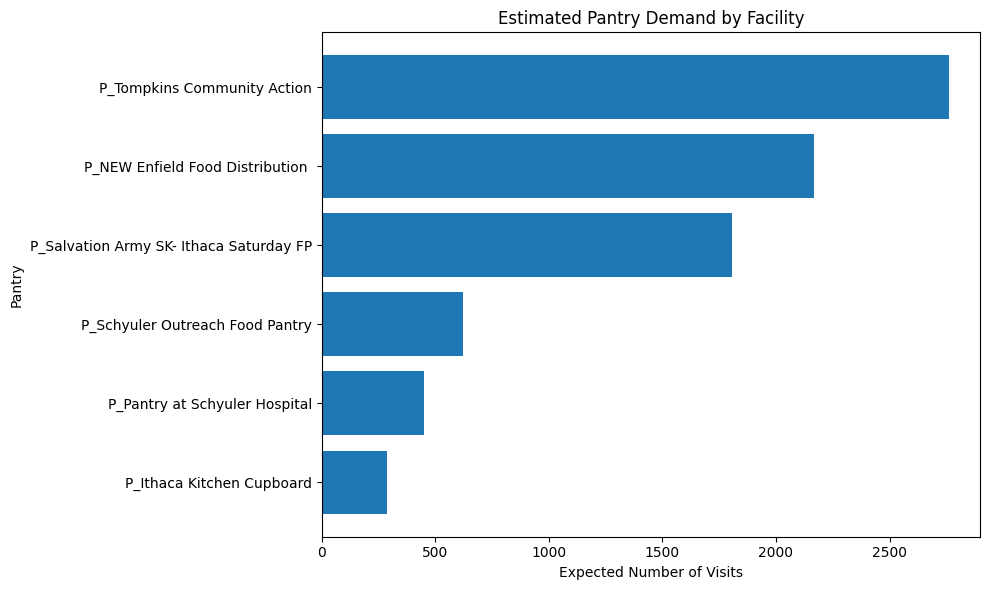

In [157]:
import matplotlib.pyplot as plt

# Sort for nicer plotting
pantry_demand = pantry_demand.sort_values(
    "expected_visits", ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    pantry_demand["best_pantry"],
    pantry_demand["expected_visits"]
)

plt.xlabel("Expected Number of Visits")
plt.ylabel("Pantry")
plt.title("Estimated Pantry Demand by Facility")

# Make numbers readable
plt.tight_layout()
plt.show()
